# Comparison Assessment Example
## Explanation:
This file is a response to an example assessment where applicants were asked to compare two sets of provided data. Some details have been removed from this response in order to make it suitable for public viewing and protect the confidentiality of the exam. This was completed over the course of two days as it was a take home project.The pseudodata files used in this project can be found in the same github repository for reference.

## Introduction
Excerpts from two datasets have been provided which describe two different sets of loan data. This code will combine the two datasets into one merged data set and consider the differences between the loans from each group.

Since there is very limited explanation of the exact meaning of each column or the format they can be expected in, some assumptions will be made about the formatting available in the full dataset. In real life the correct procedure would be to contact the person who created this dataset and clarify, however, that is not possible in this situation.

There is also a lack of clarity about if the datasets are meant to describe the same underlying loans, or two separate groups of loans. This changes the analysis because in the first case we will trying to resolve discrepancies between the two datasets, wheras in the second it is perfectly reasonable that the datasets are not identical. Due to the specific wording of the prompt, I will assume that the intent is that these two datasets describe two different groups of underlying loans, and we are simply meant to combine the datasets in a way that makes it easier to compare them to each other. We are also told that the data excerpts are not representative, so although the data in each dataset appears to be extremely similar, we cannot assume they are meant to describe the same underlying loans from this information.

To improve understanding of how the code would work and what the resulting tables and plots would look like, I have created pseudodata in the same format as already provided to test how the results might look. This data was created using excel, and I only left the loan type as 30ARM for the pseudodata as no other loan types are shown in the example.

In [1]:
#import all necessary packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates

sns.set_style('ticks')
palette = sns.color_palette(palette='Paired')

In [2]:
#import the sample data to ds_1 and ds_2
ds_1 = pd.read_csv("Dataset_1_Pseudodata.csv")
ds_2 = pd.read_csv("Dataset_2_Pseudodata.csv")

## Merge Datasets and Reformat the Result

Assumptions:
1. The outstanding_balance column in dataset 1 and 2 are in different formats. I will assume that the units of this column in dataset 1 are \\$1,000,000 while the units of this column in dataset 2 are \\$1. I make this assumption because that would bring the outstanding_balance columns in similar ranges, and it is unlikely that the outstanding_balances of the accounts in dataset 1 amount to only a few dollars. I am also assuming that the units are US dollars in the first place.
2. The month_year column will always be in a format where the first 4 numbers are the year, and the last 2 numbers indicate the month.
3. The loan types do not follow any particular format and each unique string is a different type of loan.

In [3]:
#convert both columns of outstanding_balance into floats with units of $1.

#scale oustanding_balance of dataset 1 into units of $1
ds_1['outstanding_balance'] = ds_1['outstanding_balance']*1000000

#convert outstanding_balance of dataset 2 from a string into a float
ds_2['outstanding_balance'] = ds_2['outstanding_balance'].str.replace(',','').astype(float)

In [4]:
#create merged dataset, noting which dataset each data point originates from
ds_1['dataset'] = 1
ds_2['dataset'] = 2

merged_df = pd.concat([ds_1, ds_2])

In [5]:
#format the new merged dataset properly
#convert the columns number_of_accounts and number_of_past_due_accounts from string to float
merged_df['number_of_accounts'] = merged_df['number_of_accounts'].str.replace(',','').astype(float)
merged_df['number_of_past_due_accounts'] = merged_df['number_of_past_due_accounts'].str.replace(',','').astype(float)

#change the format of the column month_year into two different columns which store the month and year separately
merged_df['year'] = merged_df['month_year'].astype(str).str.slice(0,4).astype(int)
merged_df['month'] = merged_df['month_year'].astype(str).str.slice(4,6).astype(int)

In [6]:
#create a column which stores the date in datetime format and remove month_year as it is no longer necessary
merged_df['date'] = pd.to_datetime(merged_df[['year','month']].assign(day=1))
merged_df.drop('month_year', axis=1, inplace=True)

## Analyze Dataset Differences

Questions:
1. What loan types appear in each dataset, and how many of each are there?
2. How does the number of accounts per month change over time in each dataset, and what is the average of each?
3. What is the percentage of past due accounts per month over time in each dataset and how do the averages compare?
4. What is the average outstanding balance per month in each dataset?
5. What is the average outstanding balance per mouth per past due accounts in each dataset?

### 1. What loan types appear in each datase, and how many of each are there?

In [7]:
#create a simple table which shows how many loans there are by loan type in each dataset
df_1 = merged_df[['loan_type','dataset','month']].groupby(by = ['dataset','loan_type']).count().rename(columns = {'month':'loan_count'})
df_1

,,loan_count
dataset,loan_type,
1,30ARM,36
2,30ARM,36


/tmp/ipykernel_10270/3820904930.py:2: UserWarning: The palette list has more values (12) than needed (2), which may not be intended.
  sns.countplot(merged_df, x = 'loan_type', hue = 'dataset', palette = palette)


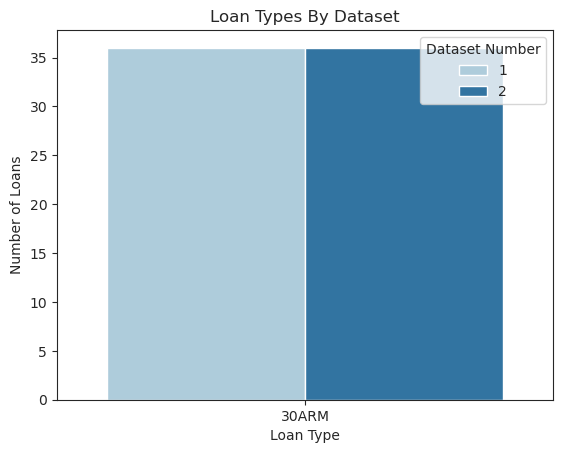

<Figure size 640x480 with 0 Axes>

In [8]:
#Create a barplot to help visually compare the differences between the number of loan types in each dataset
sns.countplot(merged_df, x = 'loan_type', hue = 'dataset', palette = palette)
plt.legend(title = 'Dataset Number')
plt.title('Loan Types By Dataset')
plt.xlabel('Loan Type')
plt.ylabel('Number of Loans')

plt.show()
plt.clf()

### 2. How does the number of accounts per month change over time in each dataset, and what are their average values and standard deviation?

Note: This section would be modified based on the results of question 1. Since we don't see more than one type of loan, we will not be sorting by the type of loan. However, if there were many types of loans and they were different frome each other all these questions would further have to be broken down by loan type.

In [9]:
#create a function to create line plot of values over time and plot average and standard deviation
#this will make plotting all the different variables easier and more consistent

def plot_analysis(var_name, var_string):
    #Create dataframe of mean and standard deviation grouped by dataset and variable of interest
    df = merged_df.groupby('dataset')[[var_name]].agg({var_name:['mean','std']})
    ds1_mean = df.loc[1,var_name].loc['mean']
    ds2_mean = df.loc[2,var_name].loc['mean']
    ds1_std = df.loc[1,var_name].loc['std']
    ds2_std = df.loc[2,var_name].loc['std']

    #set colors
    palette = {1:'#1F78B4' , 2:'#33A02C'}
    
    #plot lineplot of variable of interest
    ax = sns.lineplot(merged_df, x = 'date',y=var_name, hue = 'dataset', palette = palette)

    #labels
    plt.title(var_string+' Over Time By Dataset', fontsize = 16)
    plt.xlabel('Date', fontsize = 14)
    plt.ylabel(var_string, fontsize = 14)

    #tick format
    date_format = mdates.DateFormatter("%Y-%m")
    ax.xaxis.set_major_formatter(date_format)
    plt.xticks(rotation=20)
    ax.tick_params(axis='both', which='major', labelsize=14)

    #horizontal lines for average number of accounts with standard deviation filled in
    plt.axhline(y=ds1_mean, linestyle='--', color = '#124669',label = 'Mean of Dataset 1')
    plt.axhline(y=ds2_mean, linestyle='--', color = '#23701F',label = 'Mean of Dataset 2')
    plt.fill_between(merged_df['date'], ds1_mean - ds1_std, ds1_mean + ds1_std, alpha=0.15, color = '#A6CEE3', label = 'Std Dev of Dataset 1') 
    plt.fill_between(merged_df['date'], ds2_mean - ds2_std, ds2_mean + ds2_std, alpha=0.15, color = '#B2DF8A', label = 'Std Dev of Dataset 2')

    #legend, rename some of the legend elements to be more easily readable
    label_map = {'1':'Dataset 1', '2':'Dataset 2'}
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label_map[label] if label in label_map else label for label in labels], bbox_to_anchor=(1.01, 1), loc = 'upper left', borderaxespad=0)
    plt.rcParams.update({'font.size': 14})
    
    #show the plot and clear frame
    plt.show()
    plt.clf()

    #return the dataframe of means and standard devia
    return df

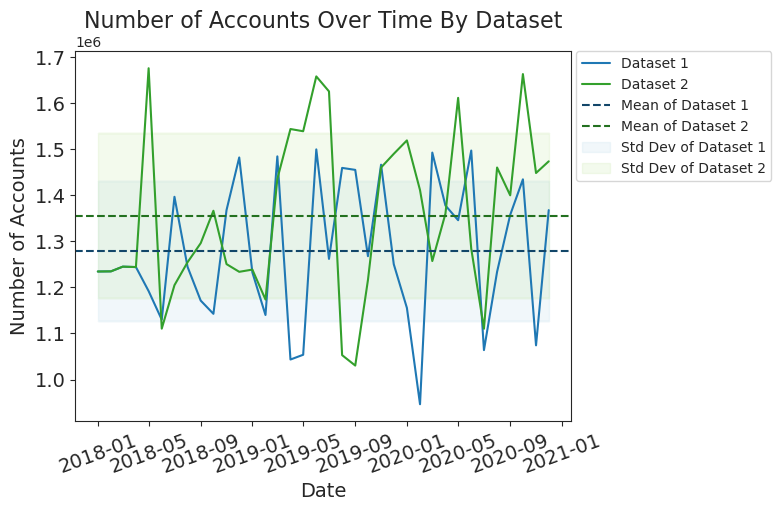

number_of_accounts               
                      mean            std
dataset                                  
1             1.279158e+06  152199.686367
2             1.355983e+06  178224.724246

<Figure size 640x480 with 0 Axes>

In [10]:
#use plot_analysis to create a graph and dataframe of information about Number of Accounts
plot_analysis(var_name = 'number_of_accounts', var_string = 'Number of Accounts')

### 3. What is the percentage of past due accounts per month over time in each dataset and how do the averages compare?

In [11]:
#Create a column showing the percentage of accounts which are past due out of the total accounts for each month
merged_df['percentage_past_due'] = merged_df['number_of_past_due_accounts']*100.0/merged_df['number_of_accounts']

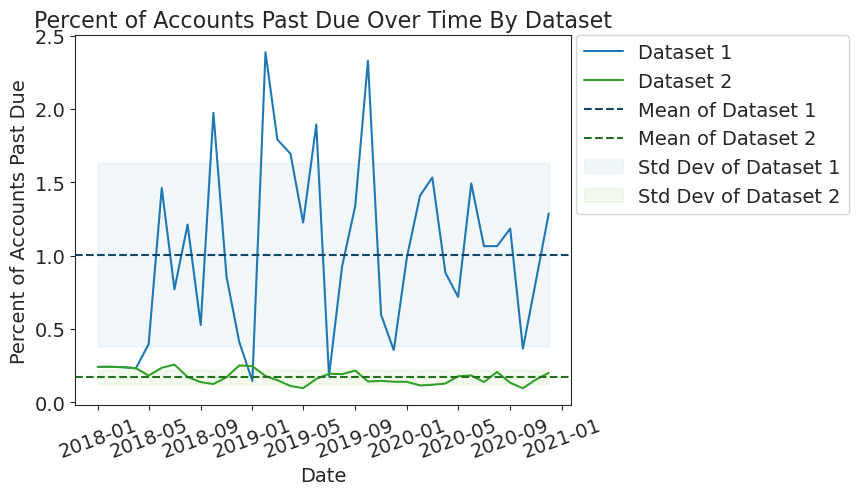

percentage_past_due          
                       mean       std
dataset                              
1                  1.007605  0.623941
2                  0.174282  0.047760

<Figure size 640x480 with 0 Axes>

In [12]:
#use plot_analysis to create a graph and dataframe of information about the percentage of accounts past due
plot_analysis(var_name = 'percentage_past_due', var_string = 'Percent of Accounts Past Due')

### 4. What is the average outstanding balance per month in each dataset?

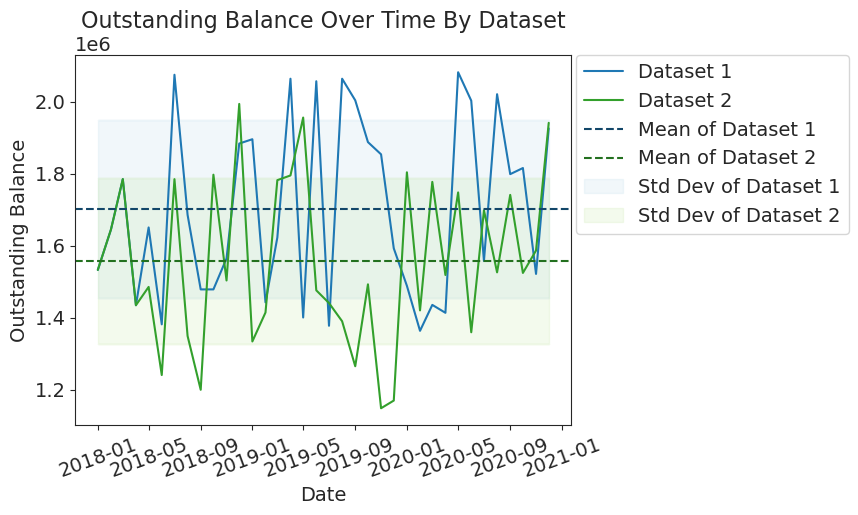

outstanding_balance               
                       mean            std
dataset                                   
1              1.702611e+06  247093.767948
2              1.557632e+06  230094.111144

<Figure size 640x480 with 0 Axes>

In [13]:
#use plot_analysis to create a graph and dataframe of information about outstanding balance
plot_analysis(var_name = 'outstanding_balance', var_string = 'Outstanding Balance')

### 5. What is the average outstanding balance per month per past due accounts in each dataset?

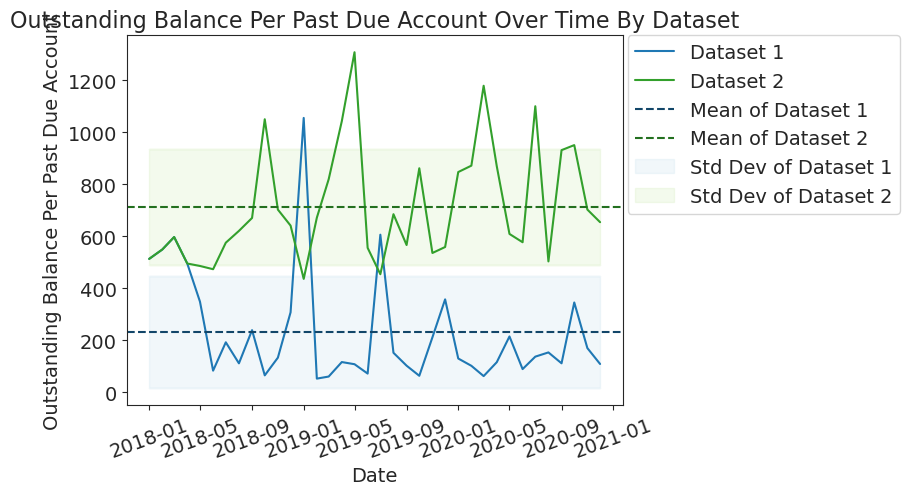

outstanding_balance_per_account            
                                   mean         std
dataset                                            
1                            231.779866  215.722060
2                            712.964928  223.100865

<Figure size 640x480 with 0 Axes>

In [14]:
#Create a column for the outstanding balance per month per past due account
merged_df['outstanding_balance_per_account'] = merged_df['outstanding_balance']*1.0/merged_df['number_of_past_due_accounts']
#use plot_analysis to create a graph and dataframe of information about the outstanding balance per past due account
plot_analysis(var_name = 'outstanding_balance_per_account', var_string = 'Outstanding Balance Per Past Due Account')

## Analysis Conclusions

The following portion below shows an example email to a boss having analyzed the data above and responding with only the plots as evidence.

Dear Boss,

I received your request for the analysis and comparison of datasets 1 and 2, and I am sending my conclusions here. I did have some questions on a few points, so I made a few assumptions about the intent of your question and the data formatting which I describe below. Please let me know if any of these are incorrect and I will update the analysis accordingly. I also created a few plots with attached tables of mean and standard deviation which I reference by title below in my explanations. 

1.	Based on the wording of the instructions, I am assuming that these two datasets are unrelated and you wish me to compare them to each other, not that they are meant to be describing the same underlying loans and I am meant to remove the differences between them. You also note that the excerpted data are not meant to be representative, so although they appear to be very similar, I will not assume that means they are describing the same underlying data.
2.	The outstanding_balance column in dataset 1 and 2 are in different formats. I assumed that the units of this column in dataset 1 are \\\$1,000,000 while the units of this column in dataset 2 are \\\$1. 
3.	I assumed that the month_year column will always be in a format where the first 4 numbers are the year, and the last 2 numbers indicate the month.

Both datasets consist of 36 months of data about 30ARM loans over the same period from January 2018 to December 2020. The number of accounts over time for each dataset are similar with an average \\\$1.28±.15 million per month for dataset 1 and \\\$1.36±.18 million per month for dataset 2, with the means both falling within the standard deviation of the other and the standard deviations being very similar. (See Number of Accounts Over Time By Dataset)

The percentage of past due accounts in each dataset are different, where the average percentage of past due accounts in dataset 1 is 1.0%±.6%, while in dataset 2 it is .17%±.05%, where the standard deviations do not overlap the other’s mean. Dataset 1 has both a higher average percentage of past due accounts, and a much higher standard deviation in the percentage of past due accounts. (See Percent of Accounts Past Due Over Time By Dataset)

Even though dataset 1 has a higher percentage of accounts past due, both datasets have similar averages and standard deviations of outstanding balance. Dataset 1 has an outstanding balance of \\\$1.70±.25 million and dataset 2 has an outstanding balance of \\\$1.56±.23 million, where the mean of each fall within the standard deviations of the other. (See Outstanding Balance Over Time By Dataset). 
This result lines up with the fact that the outstanding balance per overdue account is much higher for dataset 2 than 1, where the average outstanding balance per overdue account is \\\$713±223 for dataset 2, compared to \\\$232±216 for dataset 1. (See Outstanding Balance Per Past Due Account Over Time by Dataset)

From these results, we can see that while there are a similar number of accounts in datasets 1 and 2 which are all 30ARM loans, dataset 1 has more past due accounts with low outstanding amounts per overdue account, while dataset 2 has fewer past due accounts with high outstanding amounts per overdue account. This indicates that people in dataset 1 are more likely to have trouble repaying their loans, but only by a little, while the people in dataset 2 rarely fail to repay their loans, but when they do, they fail more severely.
I hope that this analysis answers the questions you were looking for, and please let me know if I should provide further explanation for my conclusions or if there are any other aspects I should investigate.

Best,
Employee Name